In [1]:
import sys
print(sys.executable)

c:\Users\ayaan\OneDrive\Desktop\coursera-sentiment-nlp\venv\Scripts\python.exe


In [1]:
import pandas as pd

df = pd.read_csv("Coursera_reviews.csv")  

df.head()

,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just t...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and ...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself wa...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do ...,By Dale B,"Feb 24, 2020",4,google-cbrs-cpi-training
4,Excellent course and the training provided was...,By Sean G,"Jun 18, 2020",4,google-cbrs-cpi-training


In [2]:
print(df.columns)

Index(['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id'], dtype='str')


In [3]:
def convert_rating(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(convert_rating)

df["sentiment"].value_counts()

sentiment
positive    1372866
neutral       48303
negative      33542
Name: count, dtype: int64

In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["cleaned_text"] = df["reviews"].apply(clean_text)

In [5]:
from sklearn.model_selection import train_test_split

X = df["cleaned_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

vectorizer = CountVectorizer()

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_bow, y_train)

y_pred = model.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9630718044427946
              precision    recall  f1-score   support

    negative       0.79      0.59      0.67      6611
     neutral       0.69      0.33      0.45      9689
    positive       0.97      0.99      0.98    274643

    accuracy                           0.96    290943
   macro avg       0.82      0.64      0.70    290943
weighted avg       0.96      0.96      0.96    290943



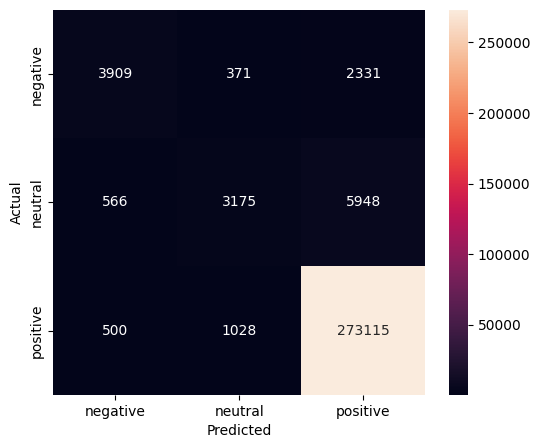

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#n gram with tf-idf

tfidf = TfidfVectorizer(
    ngram_range=(1,3),   # unigram + bigram + trigram
    max_features=20000   # limit for speed
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

TF-IDF Accuracy: 0.9562525993063934
              precision    recall  f1-score   support

    negative       0.70      0.51      0.59      6611
     neutral       0.53      0.19      0.28      9689
    positive       0.97      0.99      0.98    274643

    accuracy                           0.96    290943
   macro avg       0.73      0.57      0.62    290943
weighted avg       0.95      0.96      0.95    290943



In [9]:
#balancing minority classes and checking

# TF-IDF with unigram + bigram + trigram
tfidf = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=20000
)

# Transform data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression with class balancing
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train_tfidf, y_train)

# Predictions
y_pred_bal = model_balanced.predict(X_test_tfidf)

# Evaluation
print("Balanced TF-IDF Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Balanced TF-IDF Accuracy: 0.8858161220582725
              precision    recall  f1-score   support

    negative       0.40      0.84      0.54      6611
     neutral       0.24      0.76      0.36      9689
    positive       1.00      0.89      0.94    274643

    accuracy                           0.89    290943
   macro avg       0.54      0.83      0.62    290943
weighted avg       0.96      0.89      0.91    290943



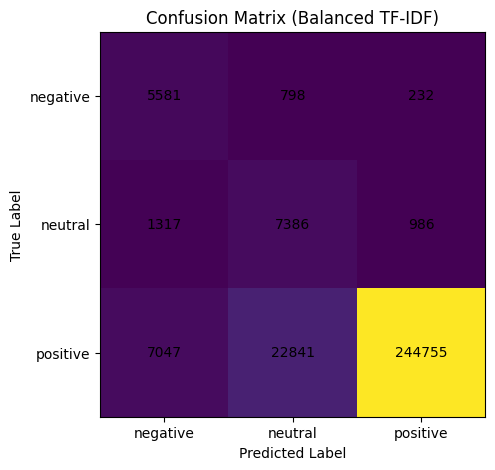

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix (Balanced TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

labels = ["negative", "neutral", "positive"]
plt.xticks(ticks=np.arange(3), labels=labels)
plt.yticks(ticks=np.arange(3), labels=labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()